In [4]:
!pip install xgboost


   ---------------------------------------- 0.0/72.0 MB ? eta -:--:--
   - -------------------------------------- 1.8/72.0 MB 10.8 MB/s eta 0:00:07
   -- ------------------------------------- 4.5/72.0 MB 11.4 MB/s eta 0:00:06
   --- ------------------------------------ 6.8/72.0 MB 11.1 MB/s eta 0:00:06
   ----- ---------------------------------- 9.2/72.0 MB 11.3 MB/s eta 0:00:06
   ------ --------------------------------- 11.8/72.0 MB 11.3 MB/s eta 0:00:06
   ------- -------------------------------- 14.2/72.0 MB 11.3 MB/s eta 0:00:06
   --------- ------------------------------ 16.5/72.0 MB 11.3 MB/s eta 0:00:05
   ---------- ----------------------------- 18.9/72.0 MB 11.3 MB/s eta 0:00:05
   ----------- ---------------------------- 21.2/72.0 MB 11.3 MB/s eta 0:00:05
   ------------- -------------------------- 23.6/72.0 MB 11.2 MB/s eta 0:00:05
   -------------- ------------------------- 25.7/72.0 MB 11.1 MB/s eta 0:00:05
   --------------- ------------------------ 27.8/72.0 MB 10.9 MB/

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from xgboost import XGBRegressor

In [11]:
df = pd.read_excel('Final_Financial_Dataset_Practical.xlsx')

In [12]:
df.head()

,name,homepage_url,category_list,market,funding_total_usd,status,country_code,state_code,region,city,...,month_4_revenue,month_5_revenue,month_6_revenue,Operating Expense,COGS,Discounts,Units Sold,MAU/AAU,Churn Rate,Expansion Revenue
0,#waywire,http://www.waywire.com,|Entertainment|Politics|Social Media|News|,News,1750000,acquired,USA,NY,New York City,New York,...,7.377459e+06,6.616146e+06,5.933349e+06,1.742239e+06,2.839177e+06,458052.098548,11976,271413,8.540925,7.382048e+06
1,&TV Communications,http://enjoyandtv.com,|Games|,Games,4000000,operating,USA,CA,Los Angeles,Los Angeles,...,4.090864e+06,3.502497e+06,3.996254e+06,1.749075e+06,1.894599e+06,401796.318229,49640,178678,5.798359,3.742446e+06
2,'Rock' Your Paper,http://www.rockyourpaper.org,|Publishing|Education|,Publishing,40000,operating,EST,NaN,Tallinn,Tallinn,...,1.478405e+06,1.391582e+06,1.401918e+06,5.369323e+05,9.419153e+05,134606.643285,34586,441856,3.142732,1.320542e+06
3,(In)Touch Network,http://www.InTouchNetwork.com,|Electronics|Guides|Coffee|Restaurants|Music|i...,Electronics,1500000,operating,GBR,NaN,London,London,...,2.944374e+06,2.760773e+06,2.650090e+06,1.396144e+06,1.258432e+06,93786.649485,5868,390485,9.976369,2.567490e+06
4,-R- Ranch and Mine,NaN,|Tourism|Entertainment|Games|,Tourism,60000,operating,USA,TX,Dallas,Fort Worth,...,4.558715e+05,4.685103e+05,4.047625e+05,1.457553e+05,1.949275e+05,14136.307787,17396,54135,9.828168,6.311658e+05


In [13]:
# Select company (example: #waywire)
company = '#waywire'
data = df[df['name'] == company]

In [14]:
# Extract last 6 months revenue
revenues = [
    data['month_1_revenue'].values[0],
    data['month_2_revenue'].values[0],
    data['month_3_revenue'].values[0],
    data['month_4_revenue'].values[0],
    data['month_5_revenue'].values[0],
    data['month_6_revenue'].values[0]
]

In [15]:
# Assume total units sold distributed equally across 6 months
total_units = data['Units Sold'].values[0]
monthly_units = total_units / 6

In [16]:
# Calculate ASP (Average Selling Price) for each month
asp = [r / monthly_units for r in revenues]

In [17]:
# Prepare data for model training
X = np.array([1, 2, 3, 4, 5, 6]).reshape(-1, 1)   # Months
y = np.array(asp)   

In [18]:
# Train XGBoost Regressor
model = XGBRegressor(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)
model.fit(X, y)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.1, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=3,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=200,
             n_jobs=None, num_parallel_tree=None, ...)

In [19]:
# Predict ASP for month 7
next_month = np.array([[7]])
predicted_asp = model.predict(next_month)[0]

print(f"Predicted ASP for next month (Month 7): {predicted_asp:.2f}")

Predicted ASP for next month (Month 7): 2972.63


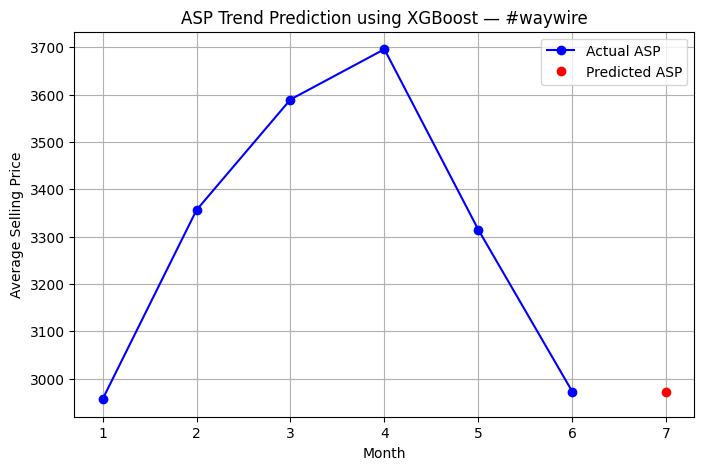

In [20]:
# Plot ASP trend
plt.figure(figsize=(8,5))
plt.plot(X, y, 'o-', label='Actual ASP', color='blue')
plt.plot(7, predicted_asp, 'ro', label='Predicted ASP')
plt.title(f"ASP Trend Prediction using XGBoost — {company}")
plt.xlabel("Month")
plt.ylabel("Average Selling Price")
plt.legend()
plt.grid(True)
plt.show()

In [16]:
#ltv

In [21]:
active_users = data['MAU/AAU'].values[0]  # Average monthly users
churn_rate = data['Churn Rate'].values[0] / 100  # Convert % → fraction

In [22]:
# Step 1️⃣ — Calculate ARPU (Average Revenue Per User)
arpu = [r / active_users for r in revenues]

# Step 2️⃣ — Estimate LTV per month
# LTV = ARPU × (1 / churn_rate)
ltv = [a * (1 / churn_rate) for a in arpu]


In [23]:

# Step 3️⃣ — Train XGBoost model
X = np.array([1, 2, 3, 4, 5, 6]).reshape(-1, 1)  # months
y = np.array(ltv)

model = XGBRegressor(n_estimators=200, learning_rate=0.1, max_depth=3, random_state=42)
model.fit(X, y)


XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.1, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=3,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=200,
             n_jobs=None, num_parallel_tree=None, ...)

In [24]:
# Step 4️⃣ — Predict LTV for next month (Month 7)
next_month = np.array([[7]])
predicted_ltv = model.predict(next_month)[0]

print(f"Predicted LTV for Month 7: {predicted_ltv:,.2f}")

Predicted LTV for Month 7: 255.96


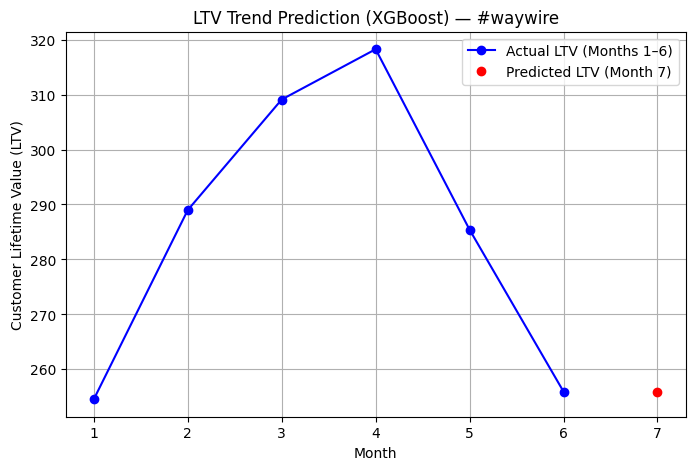

In [25]:
# Step 5️⃣ — Plot LTV trend
plt.figure(figsize=(8,5))
plt.plot(X, y, marker='o', label='Actual LTV (Months 1–6)', color='blue')
plt.plot(7, predicted_ltv, 'ro', label='Predicted LTV (Month 7)')
plt.title(f"LTV Trend Prediction (XGBoost) — {company}")
plt.xlabel("Month")
plt.ylabel("Customer Lifetime Value (LTV)")
plt.legend()
plt.grid(True)
plt.show()

In [23]:
#churnr rate

In [30]:
 #Simulate churn rate trend (± random noise for realism)
base_churn = data['Churn Rate'].values[0]
np.random.seed(42)
churn_trend = base_churn + np.random.uniform(-1, 1, 6)


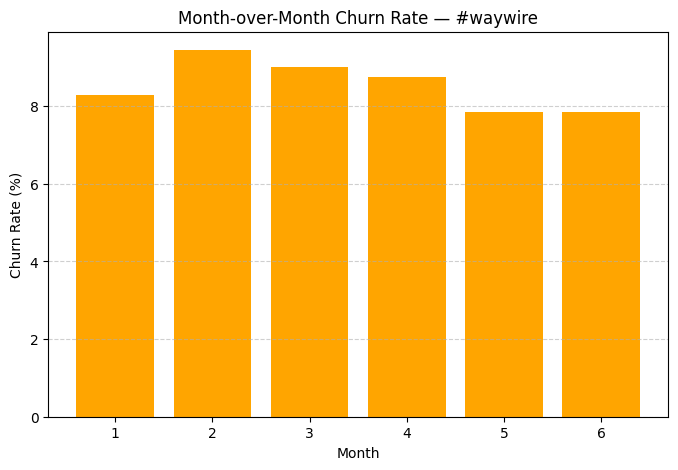

In [31]:
# ---- 📊 CHURN RATE BAR CHART ----
plt.figure(figsize=(8,5))
plt.bar(range(1, 7), churn_trend, color='orange')
plt.title(f"Month-over-Month Churn Rate — {company}")
plt.xlabel("Month")
plt.ylabel("Churn Rate (%)")
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()

In [27]:
#roi

In [32]:
#  ROI = (Net Profit / Investment) * 100
# Here, Net Profit ≈ Revenue - (Operating Expense + COGS)
operating_exp = data['Operating Expense'].values[0]
cogs = data['COGS'].values[0]
funding = data['funding_total_usd'].values[0]


In [33]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error


In [34]:
df.columns.str.strip()

Index(['name', 'homepage_url', 'category_list', 'market', 'funding_total_usd',
       'status', 'country_code', 'state_code', 'region', 'city',
       'funding_rounds', 'founded_at', 'founded_month', 'founded_quarter',
       'founded_year', 'first_funding_at', 'last_funding_at', 'seed',
       'venture', 'equity_crowdfunding', 'undisclosed', 'convertible_note',
       'debt_financing', 'angel', 'grant', 'private_equity', 'post_ipo_equity',
       'post_ipo_debt', 'secondary_market', 'product_crowdfunding', 'round_a',
       'round_b', 'round_c', 'round_d', 'round_e', 'round_f', 'round_g',
       'round_h', 'operating expenses', 'cogs', 'discounts', 'units sold',
       'mau/aau', 'churn rate', 'expansion revenue', 'beginning revenue',
       'Returns & Allowances', 'month_1_revenue', 'month_2_revenue',
       'month_3_revenue', 'month_4_revenue', 'month_5_revenue',
       'month_6_revenue', 'Operating Expense', 'COGS', 'Discounts',
       'Units Sold', 'MAU/AAU', 'Churn Rate', 'Expans

In [ ]:
monthly_revenue_cols = 